In [ ]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

In [ ]:
df.job_posted_date = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

## 🟨 Median Yearly Salary vs. Job Count (2.15.1) - Problem

* Create a scatter plot to compare the median yearly salary and the number of jobs based on the job_title_short column.
* To create the scatter plot first create a new DataFrame using the groupby() method to aggregate and find the median salary and job count for each job title.
* Annotate each point with the job title name.

In [50]:
# Group data by job title and calculate average yearly salary and job count
job_stats = df.copy().groupby('job_title_short').agg(
                                                    median_yearly_salary = ('salary_year_avg', 'median')
                                                    , job_counts = ('job_title_short', 'size')
                                                    )

job_stats = job_stats.dropna()

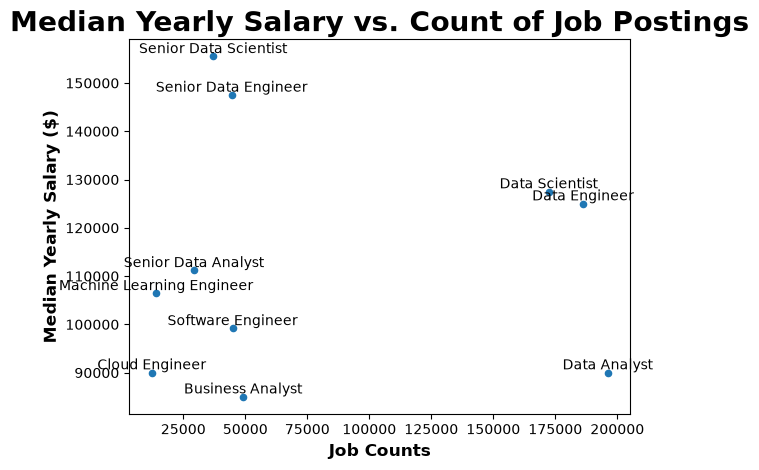

In [ ]:
# Plotting the results
job_stats.plot(
                kind='scatter'
                , x = 'job_counts'
                , y = 'median_yearly_salary')

plt.title(
        'Median Yearly Salary vs. Count of Job Postings'
        , fontdict={'fontsize': 20, 'fontweight': 'bold'}
        )

plt.xlabel('Job Counts'
            , fontdict={'fontsize': 12, 'fontweight': 'bold'}
            )

plt.ylabel(
            'Median Yearly Salary ($)'
            , fontdict={'fontsize': 12, 'fontweight': 'bold'}
            )

# Adding job title labels to each point
for index, txt in enumerate(job_stats.index):
    plt.text(
            job_stats['job_counts'].iloc[index]
            , job_stats['median_yearly_salary'].iloc[index]
            , txt
            , ha='center'
            , va='bottom'
            )

# for i in range(len(job_stats)):
#    job_count = job_stats['job_count'].iloc[i]
#    mean_salary = job_stats['median_salary_year_avg'].iloc[i]
#    job_title = job_stats.index[i]
#    plt.text(job_count, mean_salary, job_title, ha='center', va='bottom')



plt.tight_layout()
plt.show()



## 🟨 Top 7 Countries by Median Yearly Salary vs Job Count (2.15.2) - Problem

* Create a scatter plot to visualize the relationship between the number of job postings and median yearly salary for the top 7 countries based on highest number of job postings. 

* Annotate each point with the country's name.

In [52]:
Country_Stats = df.copy().groupby('job_country').agg(
                                                    median_yearly_salary = ('salary_year_avg', 'median')
                                                    , job_counts = ('job_title', 'size')
                                                    )

Country_Stats = Country_Stats.dropna().sort_values(by='job_counts', ascending=False).head(7)

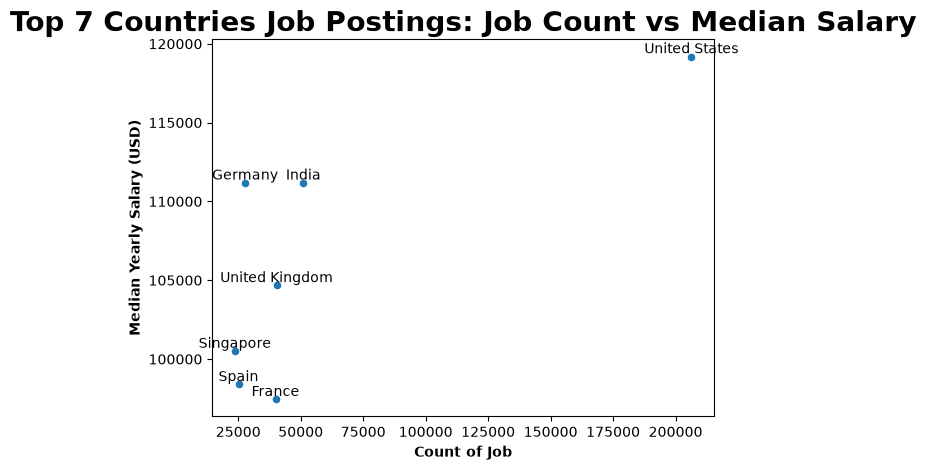

In [53]:
Country_Stats.plot(
                    kind='scatter'
                    , x='job_counts'
                    , y='median_yearly_salary'
                    )

plt.title(
            'Top 7 Countries Job Postings: Job Count vs Median Salary'
            , fontdict={'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel(
            'Count of Job'
            , fontdict={'fontsize': 10, 'fontweight': 'bold'}
            )

plt.ylabel(
            'Median Yearly Salary (USD)'
            , fontdict={'fontsize': 10, 'fontweight': 'bold'}
            )

# for index, txt in enumerate(Country_Stats.index):
#     plt.text(
#             Country_Stats['job_counts'].iloc[index]
#             , Country_Stats['median_yearly_salary'].iloc[index]
#             , txt
#             , ha = 'center'
#             , va = 'bottom')

for index in range(len(Country_Stats)):
    job_counts = Country_Stats['job_counts'].iloc[index]
    median_salary = Country_Stats['median_yearly_salary'].iloc[index]
    country = Country_Stats.index[index]
    plt.text(
        job_counts
        , median_salary
        , country
        , ha = 'center'
        , va = 'bottom'
        )

plt.tight_layout()
plt.show()

## 🟥 Average Yearly Salary vs. Job Count for Top Roles by Schedule Type (2.15.3) - Problem

* Create a scatter plot to visualize the relationship between the average yearly salary and the job count filtering a DataFrame for:
  * Data Analyst, Data Scientist, and Data Engineer positions in job_title_short
  * United States for the job_country
  * 'Full-time' and 'Contractor' for the job_schedule_type
  * Remove roles that do not have any yearly salary data.
* Combine the job_title_short and job_schedule_type into one column (called job_title_type) in the newly created DataFrame to use as the labels for the plot.
* For the plot use a for loop to cycle through the unique values in job_title_type and plot using the plt.scatter() function, specifying the label of job_title_type.
* Ensure the legend is appearing.
* Label the plot's axis and title appropriately.


In [75]:
# Define specific job titles to include

target_job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

In [68]:
# for index in range(len(target_job_titles)):
    # df_jobs = df[df['job_title_short'] == target_job_titles[index]]
                    

In [93]:
# Filter US jobs for only full-time and part-time roles and specific job titles, then drop rows with missing salary data

df_US_data_jobs = df.copy()[
                            (df['job_country'] == 'United States')
                             & df['job_title_short'].isin(target_job_titles)
                             & ((
                                 df['job_schedule_type'] == 'Full-time')
                                 | (df['job_schedule_type'] == 'Contractor'))
                            ]

df_US_data_jobs = df_US_data_jobs.copy().dropna(subset='salary_year_avg')

#Combine the job_title_short and job_schedule_type into one column (called job_title_type) in the newly created DataFrame to use as the labels for the plot.
df_US_data_jobs['job_title_type'] = df_US_data_jobs['job_title_short'] + ' - ' + df_US_data_jobs['job_schedule_type']

# Group by job schedule type and job title, calculate mean yearly salary and job count
US_data_job_stats = df_US_data_jobs.groupby('job_title_type').agg(
                                                                mean_salary = ('salary_year_avg', 'mean')
                                                                , job_data_counts = ('job_title_short', 'count')
                                                                    )

#Reset index
US_data_job_stats = US_data_job_stats.reset_index()


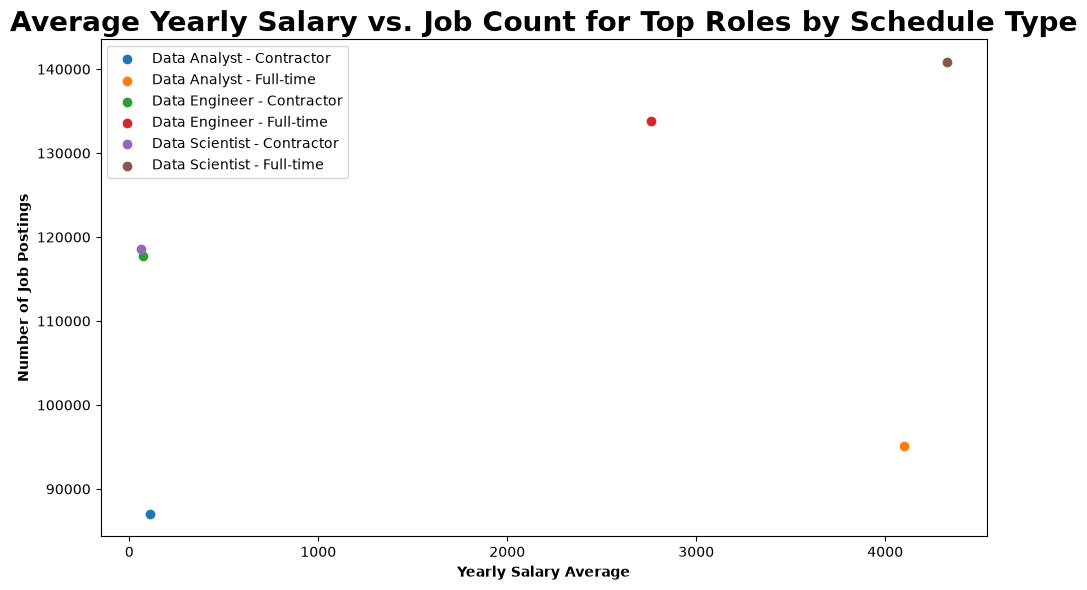

In [110]:
plt.figure(figsize=(10, 6))

for title_type in US_data_job_stats['job_title_type'].unique():
    subset_stats = US_data_job_stats[US_data_job_stats['job_title_type'] == title_type]
    plt.scatter(
                subset_stats['job_data_counts']
                , subset_stats['mean_salary']
                , label=title_type)

plt.title(
        'Average Yearly Salary vs. Job Count for Top Roles by Schedule Type'
        , fontdict={'fontsize': 20, 'fontweight': 'bold'}
        )

plt.xlabel(
        'Yearly Salary Average'
        , fontdict={'fontsize': 10, 'fontweight': 'bold'}
        )

plt.ylabel(
            'Number of Job Postings'
            , fontdict={'fontsize': 10, 'fontweight': 'bold'}
            )

# for index in range(len(US_data_job_stats['job_title_type'].unique())):
#         job_data_counts = US_data_job_stats['job_data_counts'].iloc[index]
#         mean_salary = US_data_job_stats['mean_salary'].iloc[index]
#         job_title_type = US_data_job_stats['job_title_type'].iloc[index]
#         plt.text(
#                 job_data_counts
#                 , mean_salary
#                 , job_title_type 
#                 , ha = 'center'
#                 , va = 'bottom'
#         )

plt.legend().set_visible(True)
plt.tight_layout()
plt.show()